### Problem1

Ref: https://stackoverflow.com/a/50751932

In [4]:
import numpy as np
import numpy.random as nr
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, label

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"device: {device}")

device: mps


In [5]:
h = 0.4 # Å, pixel size
L = 128 # pixels

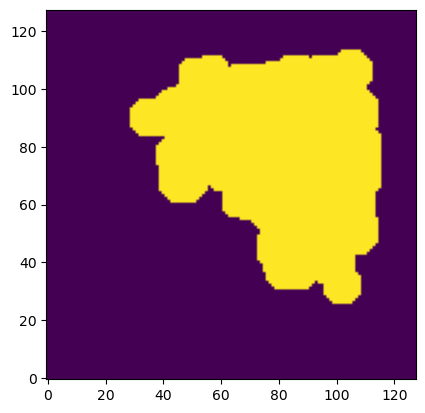

In [21]:
def randomShape(L=L, minArea=5000, maxArea=11000, maxRad=5):
    mask = np.zeros((L, L), dtype=int)

    x = np.arange(L)
    y = np.arange(L)
    X, Y = np.meshgrid(x, y)
    c = int(L/2)+1 # center
    BigCircle = ((X-c)**2 + (Y-c)**2) < 90**2 # A big circle

    go = True

    while go:
        margin = 20

        x0 = nr.randint(margin, L - margin)
        y0 = nr.randint(margin, L - margin)
        r = nr.randint(5, 10)
        circle = ((X-x0)**2 + (Y-y0)**2 - r**2) < 0

        if np.sum(circle[BigCircle==False]) > 0:
            continue

        elif (np.sum(mask) > 0) and mask[y0, x0] == False:
            continue

        else:
            mask += circle
            mask = np.clip(mask, 0, 1)

        if np.sum(mask) > minArea:
            go = False

    return mask


im = randomShape()
plt.imshow(im, origin="lower")
plt.show()